In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error

REPO_ROOT    = Path('/scratch/ralbe/meniar_and_django/smbh_hotspots_repository')
METRICS      = REPO_ROOT / 'results' / 'metrics'
NOTEBOOK_DIR = REPO_ROOT / 'notebooks' / 'figures'

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 150,
})

COLOR_NOISY = '#5B84B1'
COLOR_CLEAN = '#FC766AFF'
DEG = 180.0 / np.pi

# ── helpers ─────────────────────────────────────────────────────────

def _save(fig, name):
    p = NOTEBOOK_DIR / name
    fig.savefig(p.with_suffix('.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(p.with_suffix('.png'), dpi=300, bbox_inches='tight')


def _gaussian_fit_and_plot(ax, err, color, bins=60):
    n = len(err)
    counts, edges, _ = ax.hist(err, bins=bins, color=color, alpha=0.75, edgecolor='none')
    mu, sigma = stats.norm.fit(err)
    se_mu    = sigma / np.sqrt(n)
    se_sigma = sigma / np.sqrt(2 * n)
    bw = edges[1] - edges[0]
    xr = np.linspace(edges[0], edges[-1], 400)
    ax.plot(xr, stats.norm.pdf(xr, mu, sigma) * n * bw, color='black', lw=2)
    ax.axvline(0,  color='gray', lw=1.4, ls='--', alpha=0.8)
    ax.axvline(mu, color='red',  lw=1.8, ls='-')
    ax.errorbar(mu, counts.max() * 0.04, xerr=se_mu,
                fmt='none', color='red', capsize=5, lw=2, zorder=5)
    eqn = (f'$\mu = {mu:+.3f} \pm {se_mu:.3f}$\n'
           f'$\sigma = {sigma:.3f} \pm {se_sigma:.3f}$')
    ax.text(0.97, 0.96, eqn, transform=ax.transAxes, ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', alpha=0.92, ec='lightgray'))
    return mu, sigma, se_mu, se_sigma


def pred_vs_true_single(y_true, y_pred, symbol, error_label, color,
                        unit='', force_positive_lim=False, figsize=(9, 4)):
    """Two-panel (1x2) figure: scatter on left, error histogram on right."""
    unit_str = f' ({unit})' if unit else ''
    xlabel = f'${symbol}_{{\\mathrm{{GT}}}}${unit_str}'
    ylabel = f'$\\hat{{{symbol}}}${unit_str}'

    err = y_pred - y_true

    if force_positive_lim:
        all_v = np.concatenate([y_true, y_pred])
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        buf = (hi - lo) * 0.05
        lim = [lo - buf, hi + buf]
    else:
        lim_abs = np.nanmax(np.abs(np.concatenate([y_true, y_pred])))
        buf = lim_abs * 0.05
        lim = [-lim_abs - buf, lim_abs + buf]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    ax = axes[0]
    ax.scatter(y_true, y_pred, color=color, s=6, alpha=0.4, edgecolor='none', rasterized=True)
    ax.plot(lim, lim, 'k--', lw=1.2, alpha=0.7)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.95, f'$R^2={r2:.3f}$\nMAE={mae:.3f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9, ec='lightgray'))

    ax2 = axes[1]
    _gaussian_fit_and_plot(ax2, err, color)
    ax2.set_xlabel(error_label)
    ax2.set_ylabel('Count')

    plt.tight_layout()
    return fig


def load_test_details(exp_name, incl_scale=1.0, theta_scale=1.0):
    dfs = []
    for seed in [42, 43, 44]:
        p = METRICS / exp_name / f'test_details_seed{seed}.csv'
        if p.exists():
            df = pd.read_csv(p); df['seed'] = seed; dfs.append(df)
    if not dfs:
        return None
    df = pd.concat(dfs, ignore_index=True)
    for col in ['incl_true', 'incl_pred', 'incl_error']:
        if col in df.columns: df[col] = df[col] * incl_scale
    for col in ['theta_true', 'theta_pred', 'theta_error']:
        if col in df.columns: df[col] = df[col] * theta_scale
    return df


def load_predictions(exp_name, target, seed=43):
    p = METRICS / exp_name / f'{target}_predictions_seed{seed}.csv'
    if not p.exists():
        return None, None
    arr = np.loadtxt(p, delimiter=',', skiprows=1)
    return arr[:, 0], arr[:, 1]


def corner_plot_errors_matrix(df, targets, labels, panel_size=1.3, hist_color='#5B84B1'):
    cols = [f'{t}_error' for t in targets if f'{t}_error' in df.columns]
    if not cols:
        return None
    plot_df = df[cols].rename(
        columns={f'{t}_error': labels[t] for t in targets if f'{t}_error' in df.columns})

    hb_ref = [None]

    def diag_hist(x, **kw):
        ax = plt.gca()
        n = len(x.dropna())
        counts, edges, _ = ax.hist(x.dropna(), bins=40, color=hist_color,
                                   edgecolor='black', lw=0.4, alpha=0.85)
        mu, sigma = stats.norm.fit(x.dropna())
        se_mu    = sigma / np.sqrt(n)
        se_sigma = sigma / np.sqrt(2 * n)
        bw = edges[1] - edges[0]
        xr = np.linspace(edges[0], edges[-1], 300)
        ax.plot(xr, stats.norm.pdf(xr, mu, sigma) * n * bw, 'k-', lw=1.6)
        ax.axvline(0,  color='black', lw=1.3, ls='--')
        ax.axvline(mu, color='red',   lw=1.8)
        ax.errorbar(mu, counts.max() * 0.04, xerr=se_mu,
                    fmt='none', color='red', capsize=3, lw=1.6)
        ax.text(0.96, 0.96,
                f'$\mu={mu:+.2f}\pm{se_mu:.2f}$\n$\sigma={sigma:.2f}\pm{se_sigma:.2f}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='lightgray'))
        ax.grid(False)

    def lower_hex(x, y, **kw):
        ax = plt.gca()
        hb = ax.hexbin(x, y, gridsize=28, cmap='magma_r', bins='log', mincnt=1)
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
        ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.6)
        ax.grid(False)
        if hb_ref[0] is None:
            hb_ref[0] = hb

    g = sns.PairGrid(plot_df, corner=True, diag_sharey=False, height=panel_size)
    g.map_diag(diag_hist)
    g.map_lower(lower_hex)

    if hb_ref[0] is not None:
        cbar_ax = g.fig.add_axes([0.78, 0.57, 0.025, 0.28])
        cb = g.fig.colorbar(hb_ref[0], cax=cbar_ax)
        cb.set_label(r'$\log_{10}(N)$', rotation=270, labelpad=15)

    plt.tight_layout()
    return g.fig


def load_sweep(exp_name, target):
    p = METRICS / exp_name / f'{target}_sweep.csv'
    if not p.exists():
        return None
    df = pd.read_csv(p)
    if 'error_std_mean' in df.columns:
        df = df.rename(columns={'error_std_mean': 'mean_col', 'error_std_std': 'std_col'})
    else:
        df = df.rename(columns={'sigma_mean': 'mean_col', 'sigma_std': 'std_col'})
    return df


def plot_sweep_variant(exp_name, target, ylabel, color, label,
                       scale=1.0, marker='o', figsize=(4.5, 2.5)):
    """Plot sweep curve for a single experiment (noisy OR clean)."""
    df = load_sweep(exp_name, target)
    if df is None:
        return None
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(df['percent'], df['mean_col'] * scale,
                yerr=df['std_col'] * scale,
                marker=marker, label=label, color=color,
                capsize=4, lw=2.0, markersize=6)
    ax.set_xlabel('% of orbit used')
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    return fig

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:154: SyntaxWarning: invalid escape sequence '\m'
<>:154: SyntaxWarning: invalid escape sequence '\p'
<>:154: SyntaxWarning: invalid escape sequence '\s'
<>:154: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:154: SyntaxWarning: invalid escape sequence '\m'
<>:154: SyntaxWarning: invalid escape sequence '\p'
<>:154: SyntaxWarning: invalid escape sequence '\s'
<>:154: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_220995/2485701189.py:55: SyntaxWarning: invalid escape sequence '\m'
  eqn = (f'$\mu = {mu:+.3f} \pm {se_mu:.3f}$\n'
/tmp/ipykernel_220995/2485701189.py:55: Synt

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Mono'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


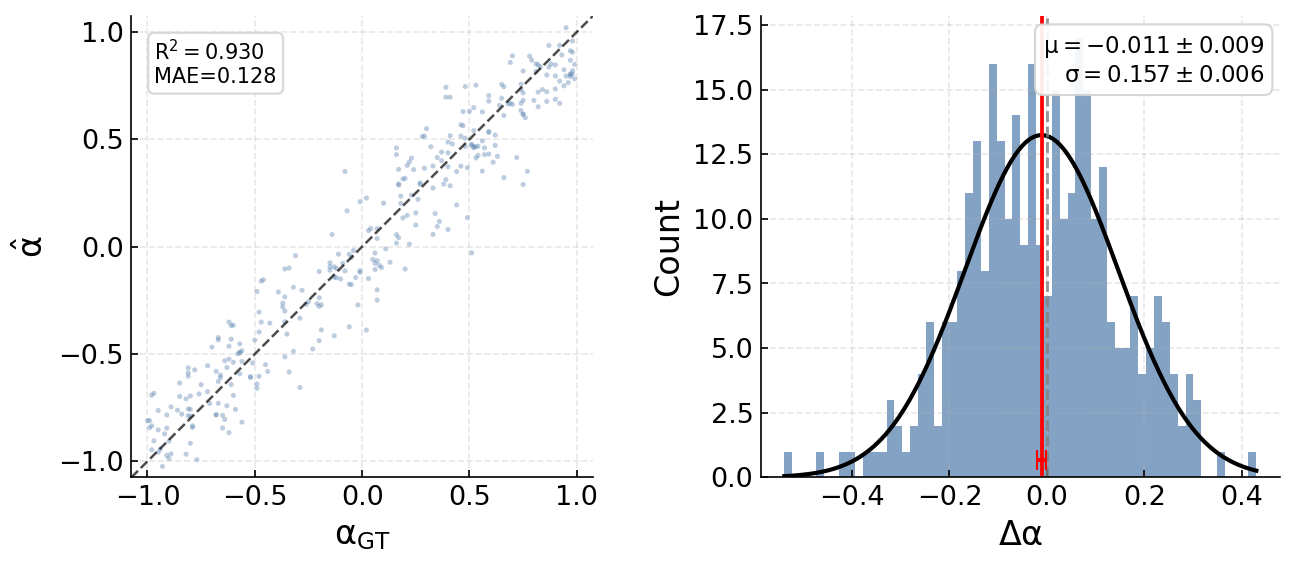

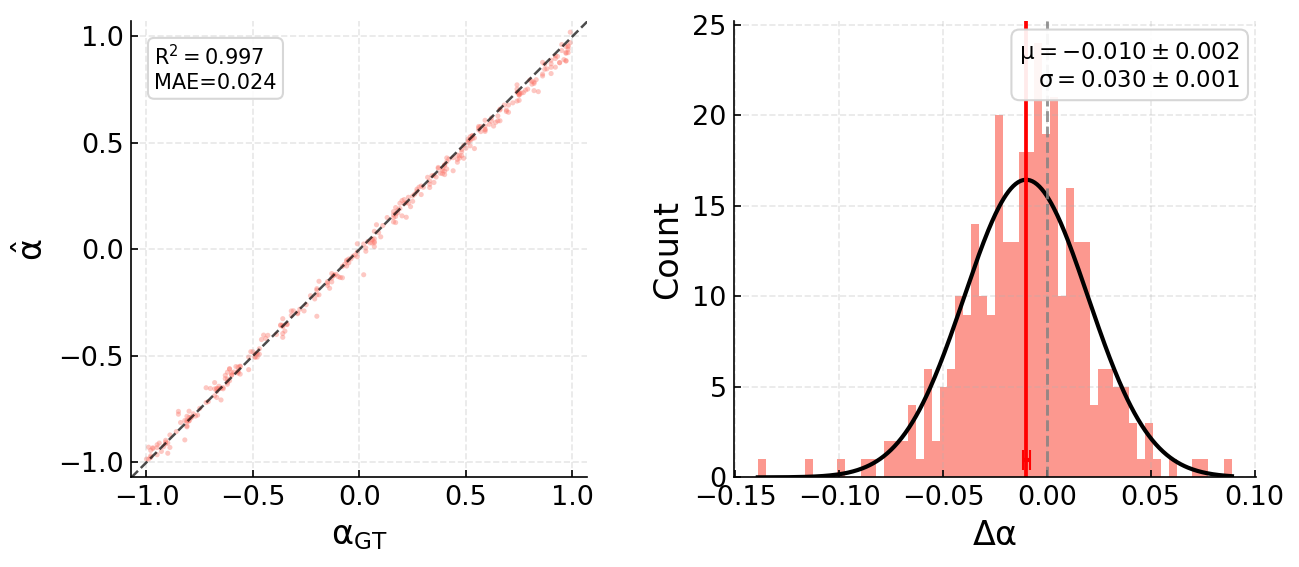

In [2]:
# Experiment I – Spin (seed 43)

yt_noisy, yp_noisy = load_predictions('experiment_1_eq_avg',          'spin', seed=43)
yt_clean, yp_clean = load_predictions('experiment_1_eq_avg_no_noise', 'spin', seed=43)

fig = pred_vs_true_single(yt_noisy, yp_noisy,
                          symbol=r'\alpha', error_label=r'$\Delta\alpha$',
                          color=COLOR_NOISY, figsize=(9, 4))
_save(fig, 'exp1_spin_pred_vs_true_noisy')
plt.show()

fig = pred_vs_true_single(yt_clean, yp_clean,
                          symbol=r'\alpha', error_label=r'$\Delta\alpha$',
                          color=COLOR_CLEAN, figsize=(9, 4))
_save(fig, 'exp1_spin_pred_vs_true_clean')
plt.show()

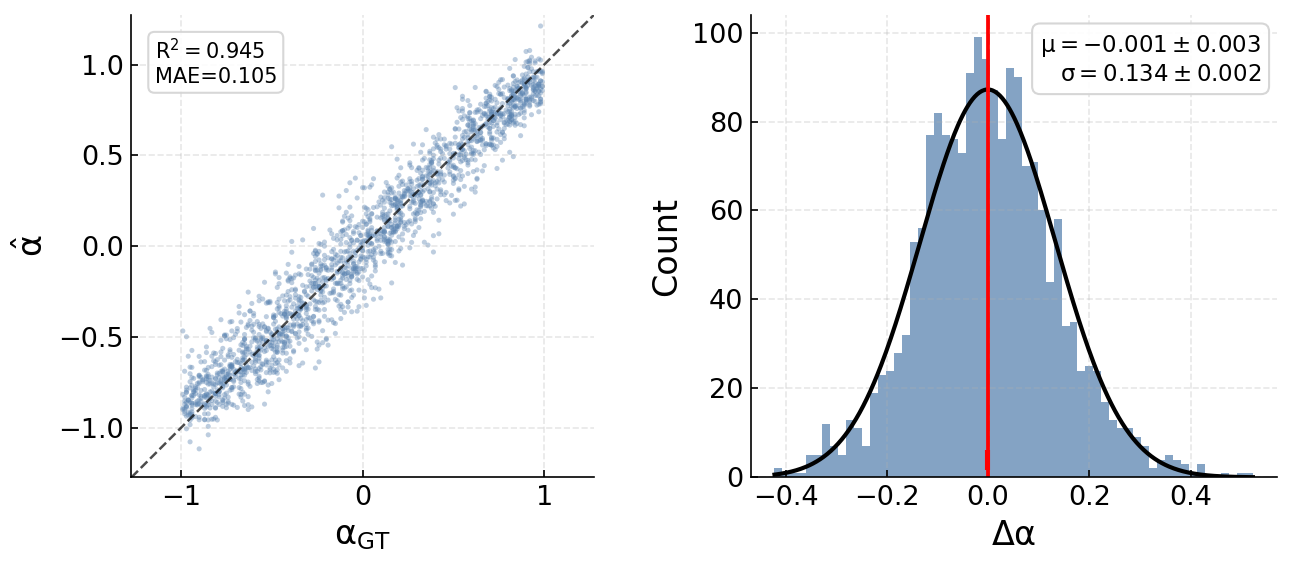

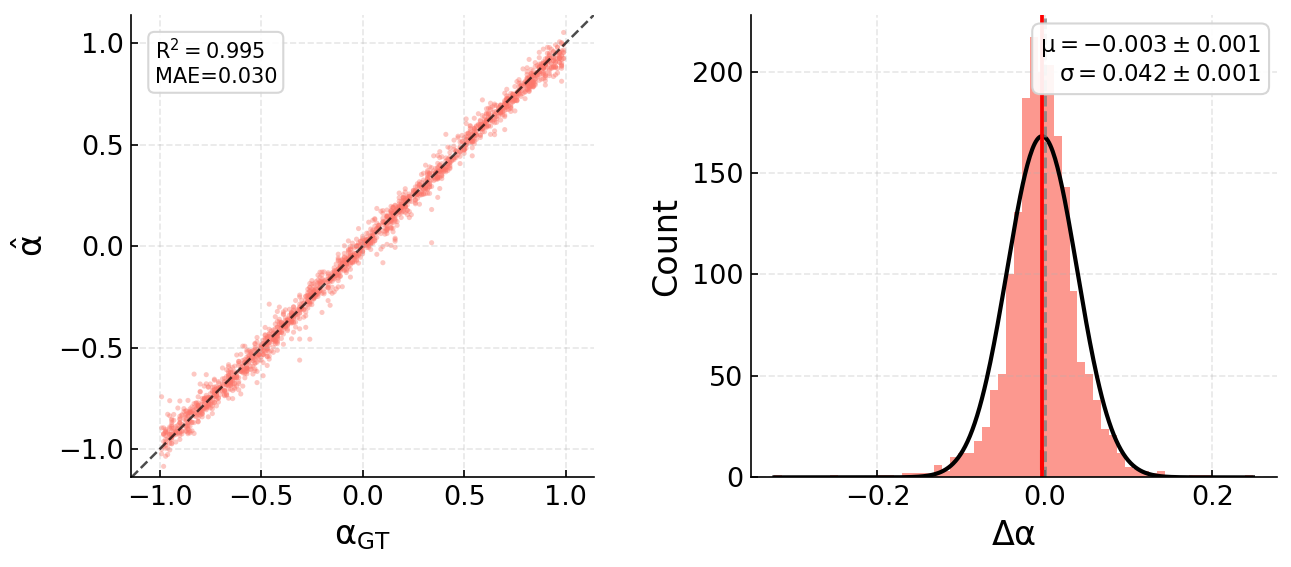

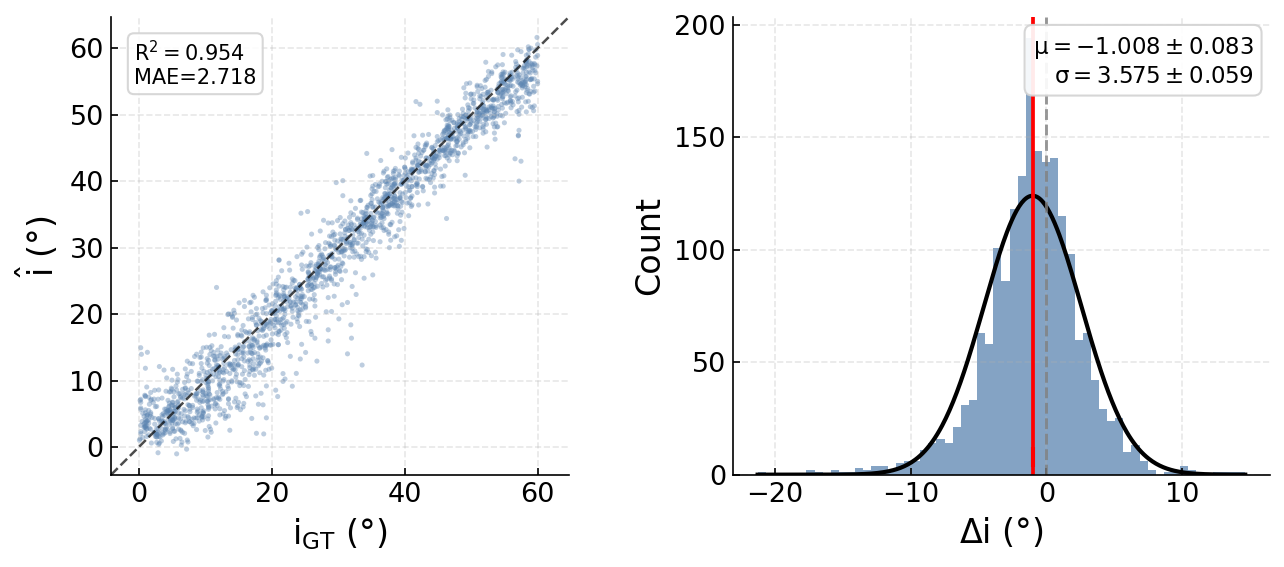

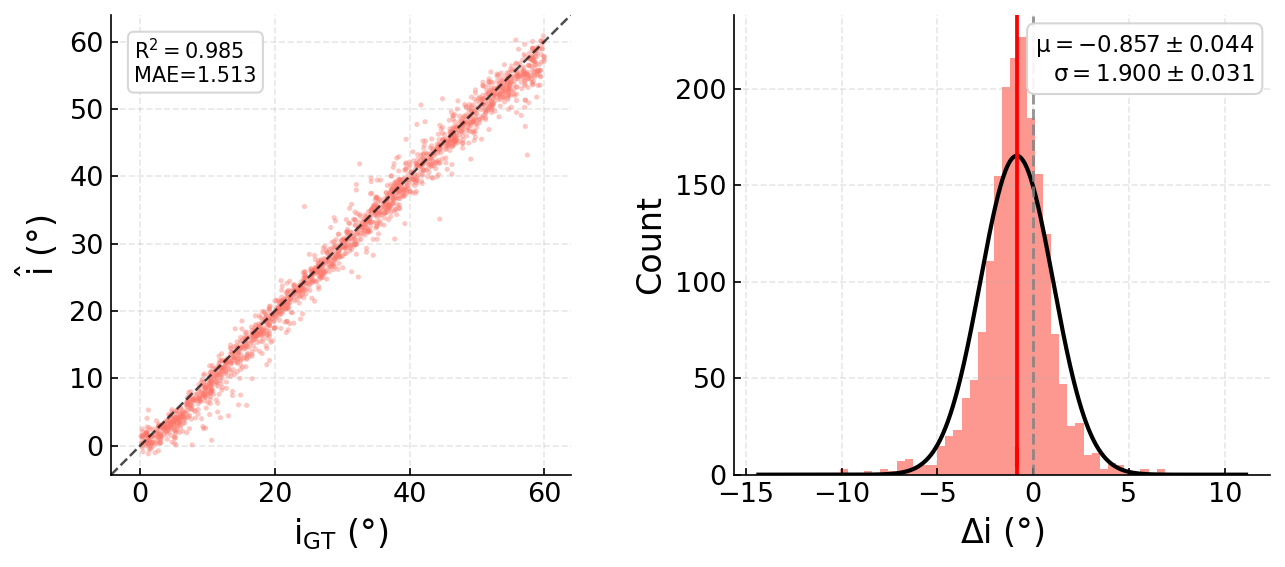

In [3]:
# Experiment II – Spin and Inclination (all seeds)

df2_noisy = load_test_details('experiment_2_eq_full',          incl_scale=DEG)
df2_clean = load_test_details('experiment_2_eq_full_no_noise', incl_scale=DEG)

# Spin
fig = pred_vs_true_single(df2_noisy['spin_true'].values, df2_noisy['spin_pred'].values,
                          symbol=r'\alpha', error_label=r'$\Delta\alpha$',
                          color=COLOR_NOISY, figsize=(9, 4))
_save(fig, 'exp2_spin_pred_vs_true_noisy')
plt.show()

fig = pred_vs_true_single(df2_clean['spin_true'].values, df2_clean['spin_pred'].values,
                          symbol=r'\alpha', error_label=r'$\Delta\alpha$',
                          color=COLOR_CLEAN, figsize=(9, 4))
_save(fig, 'exp2_spin_pred_vs_true_clean')
plt.show()

# Inclination
fig = pred_vs_true_single(df2_noisy['incl_true'].values, df2_noisy['incl_pred'].values,
                          symbol='i', error_label=r'$\Delta i$ (°)', unit='°',
                          color=COLOR_NOISY, force_positive_lim=True, figsize=(9, 4))
_save(fig, 'exp2_incl_pred_vs_true_noisy')
plt.show()

fig = pred_vs_true_single(df2_clean['incl_true'].values, df2_clean['incl_pred'].values,
                          symbol='i', error_label=r'$\Delta i$ (°)', unit='°',
                          color=COLOR_CLEAN, force_positive_lim=True, figsize=(9, 4))
_save(fig, 'exp2_incl_pred_vs_true_clean')
plt.show()

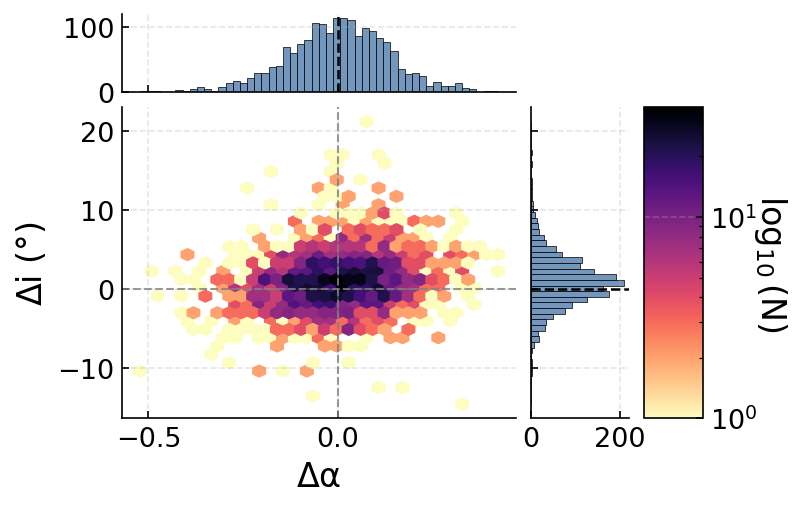

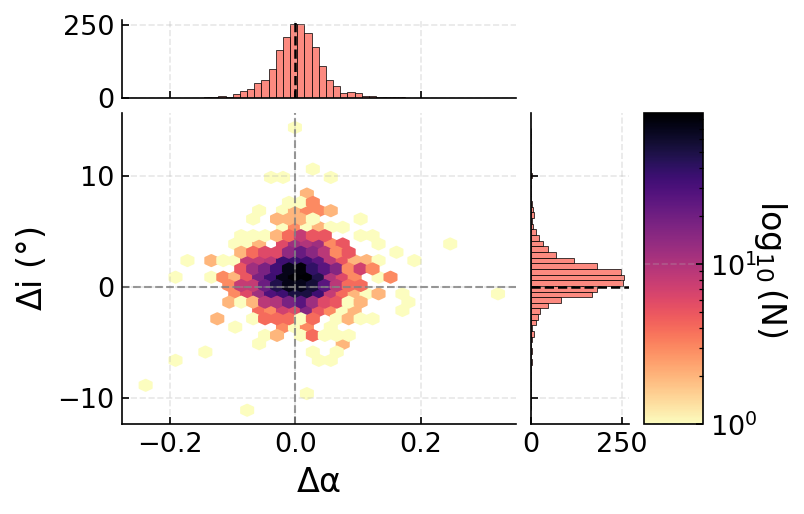

In [4]:
# Experiment II – Corner plot Delta_alpha vs Delta_i (separate noisy / clean)
# df2_noisy / df2_clean defined in cell above

for df_det, suffix, hist_color in [
    (df2_noisy, 'noisy', COLOR_NOISY),
    (df2_clean, 'clean', COLOR_CLEAN),
]:
    fig = plt.figure(figsize=(5, 3.5))
    gs = fig.add_gridspec(2, 3,
                          width_ratios=(4, 1, 0.6),
                          height_ratios=(1, 4),
                          wspace=0.08, hspace=0.08)
    ax_main  = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)
    ax_cb    = fig.add_subplot(gs[1, 2])

    x = df_det['spin_error'].values
    y = df_det['incl_error'].values

    hb = ax_main.hexbin(x, y, gridsize=30, cmap='magma_r', bins='log', mincnt=1)
    ax_main.axhline(0, color='gray', ls='--', lw=1.0, alpha=0.8)
    ax_main.axvline(0, color='gray', ls='--', lw=1.0, alpha=0.8)
    ax_main.set_xlabel(r'$\Delta\alpha$')
    ax_main.set_ylabel(r'$\Delta i$ (°)')

    cb = fig.colorbar(hb, cax=ax_cb)
    cb.set_label(r'$\log_{10}(N)$', rotation=270, labelpad=15)

    hkw = dict(bins=50, color=hist_color, edgecolor='black', lw=0.4, alpha=0.85)
    ax_histx.hist(x, **hkw)
    ax_histy.hist(y, orientation='horizontal', **hkw)
    ax_histx.axvline(0, color='black', lw=1.2, ls='--')
    ax_histy.axhline(0, color='black', lw=1.2, ls='--')
    ax_histx.tick_params(labelbottom=False)
    ax_histy.tick_params(labelleft=False)

    _save(fig, f'exp2_corner_{suffix}')
    plt.show()

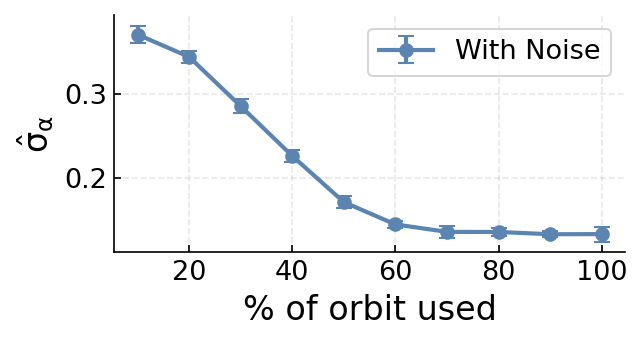

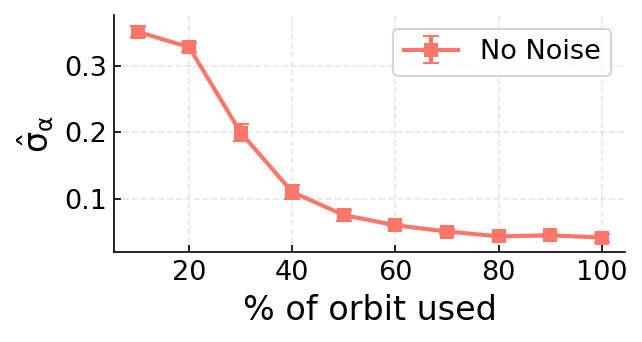

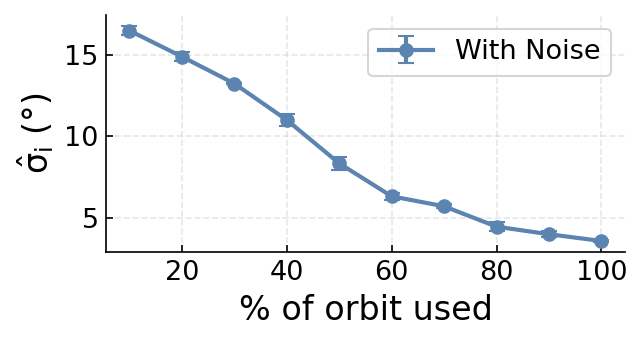

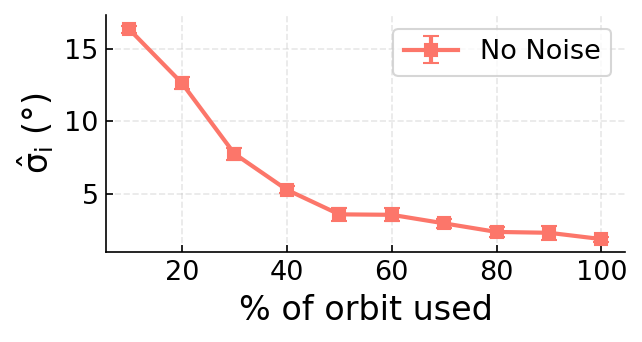

In [5]:
# Experiment III – sigma vs orbit coverage (split: noisy vs clean)

EXP3       = 'experiment_3_eq_partial'
EXP3_CLEAN = 'experiment_3_eq_partial_no_noise'

for target, (ylabel, scale) in [
    ('spin', (r'$\hat{\sigma}_\alpha$',     1.0)),
    ('incl', (r'$\hat{\sigma}_i$ (°)',      DEG)),
]:
    fig = plot_sweep_variant(EXP3, target, ylabel=ylabel, scale=scale,
                             color=COLOR_NOISY, label='With Noise', marker='o',
                             figsize=(4.5, 2.5))
    if fig is not None:
        _save(fig, f'exp3_{target}_sweep_noisy')
        plt.show()

    fig = plot_sweep_variant(EXP3_CLEAN, target, ylabel=ylabel, scale=scale,
                             color=COLOR_CLEAN, label='No Noise', marker='s',
                             figsize=(4.5, 2.5))
    if fig is not None:
        _save(fig, f'exp3_{target}_sweep_clean')
        plt.show()

In [6]:
# Experiment IV – corner error plot
# Set EXTRA_TARGET to 'theta' or 'z'
EXTRA_TARGET = 'theta'   # <-- change to 'z' if preferred

assert EXTRA_TARGET in ('theta', 'z')

# For theta / z we use the neq45 dataset (larger theta coverage).
# Spin/incl-only and corners-with-extras both load the merged exp4 (neq45 dataset).
if EXTRA_TARGET in ('theta', 'z'):
    EXP_NOISY = 'experiment_4_noneq_full_neq45_neq45'
    EXP_CLEAN = 'experiment_4_noneq_full_neq45_neq45_no_noise'
    exp_tag   = 'exp4_neq45'
else:
    EXP_NOISY = 'experiment_4_noneq_full_neq45'
    EXP_CLEAN = 'experiment_4_noneq_full_neq45_neq45_no_noise'
    exp_tag   = 'exp4'

df_noisy = load_test_details(EXP_NOISY, incl_scale=DEG, theta_scale=DEG)
df_clean = load_test_details(EXP_CLEAN, incl_scale=DEG, theta_scale=DEG)

LABELS = {
    'spin':  r'$\Delta\alpha$',
    'incl':  r'$\Delta i$ (°)',
    'theta': r'$\Delta\theta$ (°)',
    'z':     r'$\Delta z$ (M)',
}
targets_to_plot = ['spin', 'incl', EXTRA_TARGET]

for df_det, suffix, hist_color in [
    (df_noisy, 'noisy', COLOR_NOISY),
    (df_clean, 'clean', COLOR_CLEAN),
]:
    if df_det is None:
        print(f'[skip] no {suffix} results for {EXP_NOISY if suffix == "noisy" else EXP_CLEAN}')
        continue
    fig = corner_plot_errors_matrix(df_det, targets_to_plot, LABELS,
                                    panel_size=1.7, hist_color=hist_color)
    _save(fig, f'{exp_tag}_corner_{EXTRA_TARGET}_{suffix}')
    plt.show()

[skip] no noisy results for experiment_4_noneq_full_neq45_neq45
[skip] no clean results for experiment_4_noneq_full_neq45_neq45_no_noise


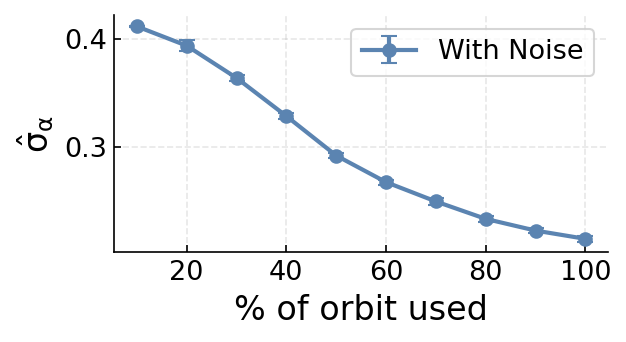

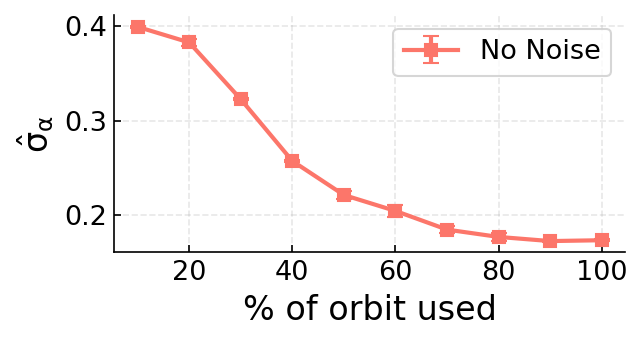

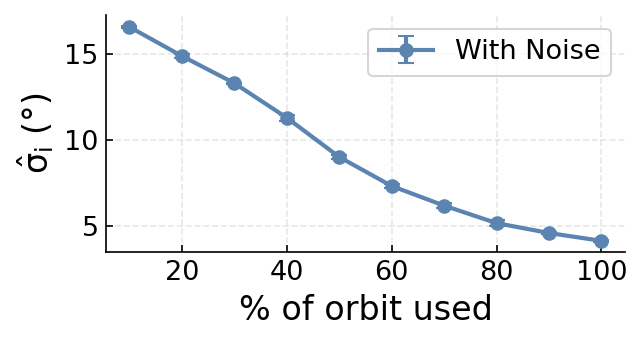

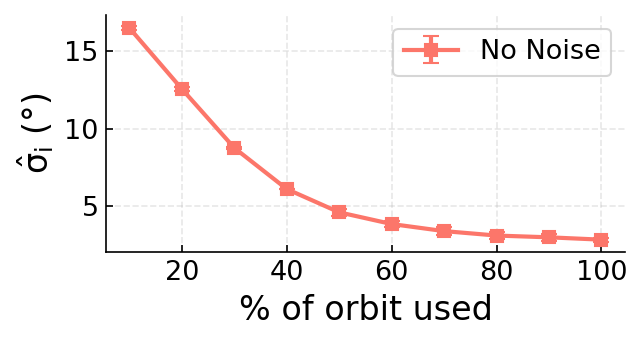

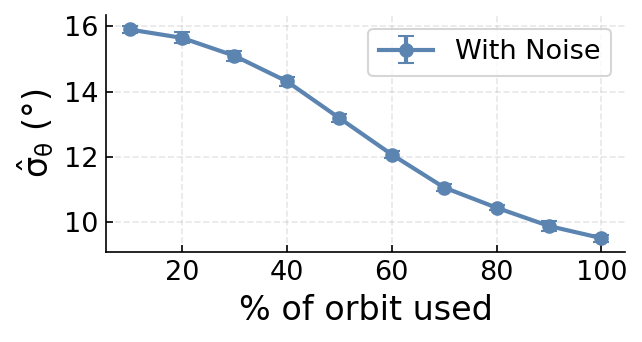

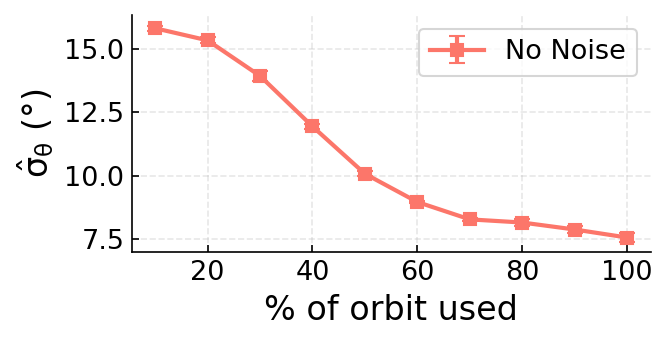

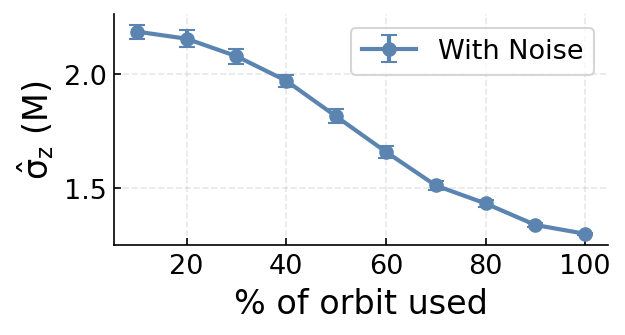

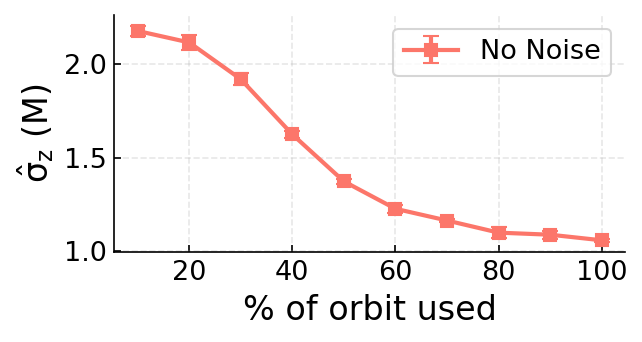

In [7]:
# Experiment V – sigma vs orbit coverage (one plot per target, split noisy/clean)
# For theta / z we use the neq45 dataset (larger theta coverage).

EXP5       = 'experiment_5_noneq_partial_neq45'
EXP5_CLEAN = 'experiment_5_noneq_partial_neq45_no_noise'
EXP11      = 'experiment_5_noneq_partial_neq45'
EXP11_CLEAN = 'experiment_5_noneq_partial_neq45_no_noise'

SWEEP_TARGETS = {
    'spin':  (r'$\hat{\sigma}_\alpha$',     1.0),
    'incl':  (r'$\hat{\sigma}_i$ (°)',      DEG),
    'theta': (r'$\hat{\sigma}_\theta$ (°)', DEG),
    'z':     (r'$\hat{\sigma}_z$ (M)',      1.0),
}

for target, (ylabel, scale) in SWEEP_TARGETS.items():
    if target in ('theta', 'z'):
        exp_n, exp_c, tag = EXP11, EXP11_CLEAN, 'exp11'
    else:
        exp_n, exp_c, tag = EXP5, EXP5_CLEAN, 'exp5'

    fig = plot_sweep_variant(exp_n, target, ylabel=ylabel, scale=scale,
                             color=COLOR_NOISY, label='With Noise', marker='o',
                             figsize=(4.5, 2.5))
    if fig is not None:
        _save(fig, f'{tag}_{target}_sweep_noisy')
        plt.show()

    fig = plot_sweep_variant(exp_c, target, ylabel=ylabel, scale=scale,
                             color=COLOR_CLEAN, label='No Noise', marker='s',
                             figsize=(4.5, 2.5))
    if fig is not None:
        _save(fig, f'{tag}_{target}_sweep_clean')
        plt.show()